In [ ]:
import kagglehub
import yaml
from pathlib import Path
import os

print("="*60)
print("STEP 1: DATASET PREPARATION")
print("="*60)

# Download Dataset (Cached on subsequent runs)
try:
    path = kagglehub.dataset_download("gabrielfcarvalho/cardd-with-yolo-annotations-images-labels")
    print(f"✅ Dataset path: {path}")
except Exception as e:
    print(f"⚠️ Using cached path: {e}")
    path = "/kaggle/input/cardd-with-yolo-annotations-images-labels"

# Generate YOLO Config - Use underscores for class names (YOLO standard)
damage_categories = ['dent', 'scratch', 'crack', 'glass_shatter', 'lamp_broken', 'tire_flat']

yaml_data = {
    'path': path,
    'train': 'train/images',
    'val': 'val/images',
    'test': 'test/images',
    'nc': len(damage_categories),
    'names': damage_categories  # Underscores, not spaces
}

yaml_path = Path("cardd_dataset.yaml")
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_data, f, default_flow_style=False)

print(f"✅ Config saved to: {yaml_path.absolute()}")
print(f"📋 Classes: {damage_categories}")

STEP 1: DATASET PREPARATION
Using Colab cache for faster access to the 'cardd-with-yolo-annotations-images-labels' dataset.
✅ Dataset path: /kaggle/input/cardd-with-yolo-annotations-images-labels
✅ Config saved to: /content/cardd_dataset.yaml
📋 Classes: ['dent', 'scratch', 'crack', 'glass_shatter', 'lamp_broken', 'tire_flat']


In [ ]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 40.7 MB/s eta 0:00:00


In [ ]:
import os, sys, shutil, argparse, torch, importlib
from ultralytics import YOLO

# ==============================================================================
# PYTORCH 2.6+ COMPATIBILITY PATCH
# ==============================================================================
def apply_factory_reset_patch():
    import torch.serialization
    importlib.reload(torch.serialization)
    original_load = torch.serialization.load
    def safe_load(*args, **kwargs):
        if 'weights_only' in kwargs:
            kwargs['weights_only'] = False
        return original_load(*args, **kwargs)
    torch.load = safe_load
    torch.serialization.load = safe_load
    print("✅ PyTorch 2.6+ patch applied.")

apply_factory_reset_patch()
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'

print("\n" + "="*60)
print("STEP 2: TRAINING (YOLOv8s | 75 Epochs | Optimized)")
print("="*60)

device = '0' if torch.cuda.is_available() else 'cpu'
print(f"🖥️ Device: {device.upper()}")

# ✅ USE DETECTION MODEL (not segmentation) - CarDD has bbox-only annotations
print("📦 Loading YOLOv8s pretrained weights...")
model = YOLO('yolov8s.pt')  # ← Changed from 'yolov8s-seg.pt'

train_args = {
    'data': str(yaml_path),
    'epochs': 75,
    'batch': 16,
    'imgsz': 640,
    'device': device,
    'optimizer': 'AdamW',

    # Loss & Optimization
    'lr0': 0.001,
    'lrf': 0.01,
    'momentum': 0.937,
    'weight_decay': 0.0005,
    'warmup_epochs': 3.0,

    # Accuracy Boosters
    'cos_lr': True,           # Cosine LR decay
    'close_mosaic': 10,       # Stop mosaic late for sharper boxes
    'patience': 50,           # Early stopping
    'box': 7.5,               # Box loss gain
    'cls': 1.0,               # ↑ Class loss for rare classes (crack/scratch)
    'dfl': 1.5,               # Distribution focal loss

    # Augmentation (conservative for small dataset)
    'hsv_h': 0.015,
    'hsv_s': 0.7,
    'hsv_v': 0.4,
    'degrees': 0.0,           # No rotation (vehicles are upright)
    'translate': 0.1,
    'scale': 0.5,
    'fliplr': 0.5,            # Horizontal flip OK for vehicles

    # Project Settings
    'project': 'runs/train',
    'name': 'damage_detect_v2',
    'exist_ok': True,
    'save': True,
    'plots': True,
    'val': True,
    'verbose': True
}

print("🚀 Starting training...")
try:
    results = model.train(**train_args)

    # Save best model to root for easy access
    best_path = 'runs/train/damage_detect_v2/weights/best.pt'
    if os.path.exists(best_path):
        shutil.copy(best_path, 'best_damage_model.pt')
        print(f"\n✅ Training Complete! Model saved as 'best_damage_model.pt'")

        # Print final metrics
        metrics = results.results_dict
        print(f"\n📊 Final Validation Metrics:")
        print(f"   mAP@0.5: {metrics.get('metrics/mAP_50', 'N/A'):.3f}")
        print(f"   mAP@0.5:0.95: {metrics.get('metrics/mAP_50-95', 'N/A'):.3f}")
    else:
        print("\n❌ best.pt not found.")

except Exception as e:
    print(f"\n❌ Training failed: {e}")
    import traceback
    traceback.print_exc()

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ PyTorch 2.6+ patch applied.

STEP 2: TRAINING (YOLOv8s | 75 Epochs | Optimized)
🖥️ Device: 0
📦 Loading YOLOv8s pretrained weights...
🚀 Starting training...
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=1.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=cardd_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=75, erasing=0.4, exis

In [ ]:
import os
from ultralytics import YOLO

print("="*60)
print("STEP 3: EXPORT TO ONNX")
print("="*60)

if os.path.exists('/content/runs/detect/runs/train/damage_detect_v2/weights/best.pt'):
    print("📦 Exporting to ONNX (Dynamic + Half Precision)...")
    model = YOLO('/content/runs/detect/runs/train/damage_detect_v2/weights/best.pt')

    # Export with dynamic batch/image sizes & FP16 for faster inference
    export_path = model.export(
        format='onnx',
        dynamic=True,
        half=True,      # FP16 for 2x speedup on supported hardware
        simplify=True,  # Optimize graph
        opset=12        # Compatible with most runtimes
    )

    print(f"✅ ONNX model exported to: {export_path}")
    print("💡 Use this .onnx file with:")
    print("   - ONNX Runtime (Python/C#/Java)")
    print("   - OpenCV DNN module")
    print("   - TensorRT (NVIDIA GPUs)")
    print("   - Web via ONNX.js or WebAssembly")
else:
    print("❌ best_damage_model.pt not found. Train first.")

STEP 3: EXPORT TO ONNX
📦 Exporting to ONNX (Dynamic + Half Precision)...
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 11,127,906 parameters, 0 gradients, 28.4 GFLOPs

PyTorch: starting from '/content/runs/detect/runs/train/damage_detect_v2/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 10, 8400) (21.5 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0,<2.0.0', 'onnxslim>=0.1.71', 'onnxruntime-gpu'] not found, attempting AutoUpdate...
Using Python 3.12.13 environment at: /usr
Resolved 12 packages in 291ms
Prepared 4 packages in 6.87s
Installed 4 packages in 470ms
 + colorama==0.4.6
 + onnx==1.21.0
 + onnxruntime-gpu==1.24.4
 + onnxslim==0.1.90

requirements: AutoUpdate success ✅ 8.3s
WARNING ⚠️ requirements: Restart runtime or rerun c

✅ PyTorch 2.6+ patch applied
STEP 4: INFERENCE & ANALYSIS
📦 Loading model from: runs/detect/runs/train/damage_detect_v2/weights/best.pt
✅ Model loaded. Classes: ['dent', 'scratch', 'crack', 'glass_shatter', 'lamp_broken', 'tire_flat']
📂 Analyzing 3 images...

📷 Processing 3 images...

📄 Saving report: analysis_results\report_20260410_145305.json
🖼️ Visualizations: analysis_results\visualizations

👁️ Preview: 000018.jpg


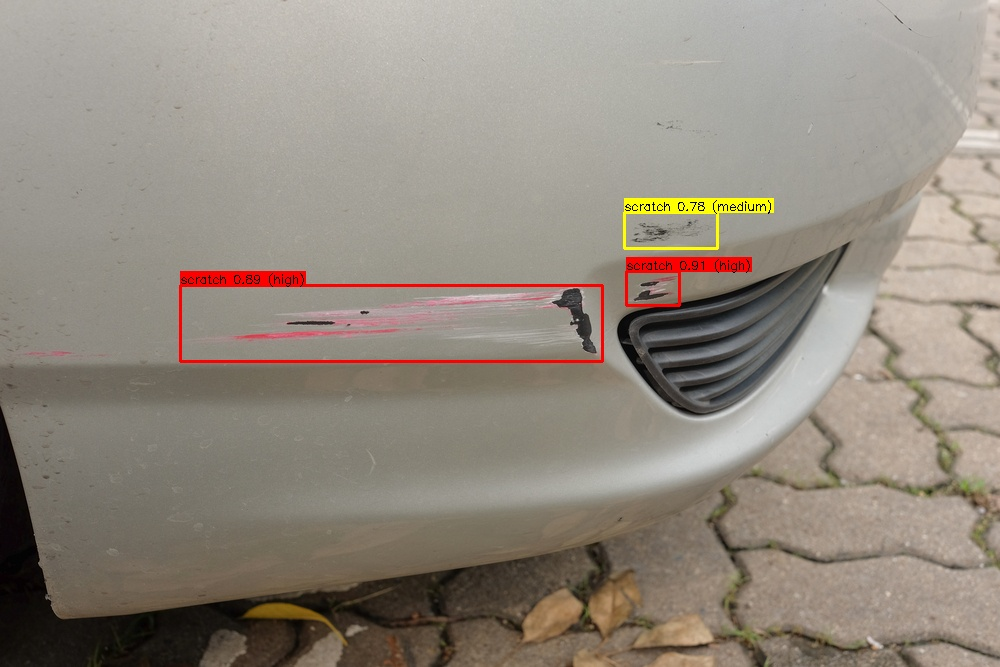

👁️ Preview: 000019.jpg


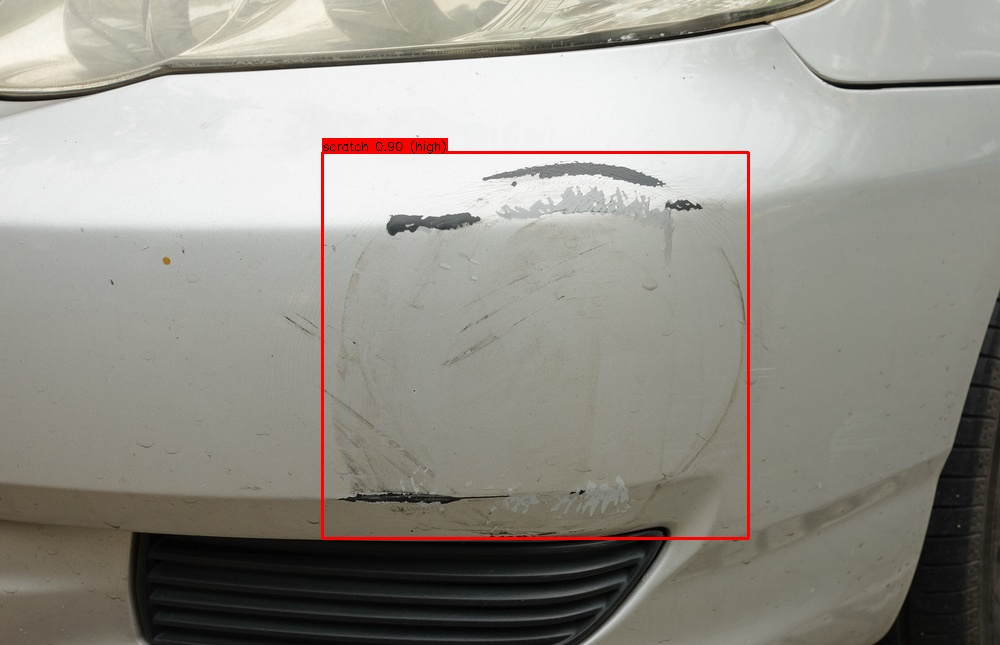

👁️ Preview: 000021.jpg


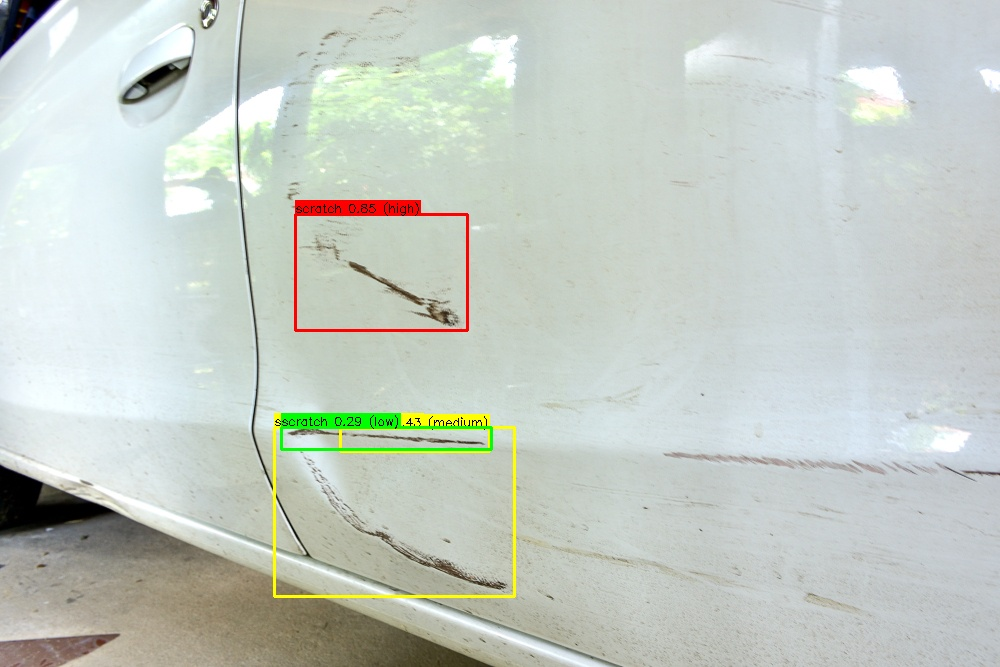


✅ Analysis complete! Total damages detected: 8


In [11]:
# ==============================================================================
# PYTORCH 2.6+ COMPATIBILITY PATCH - MUST RUN BEFORE IMPORTING YOLO
# ==============================================================================
import os, sys, importlib, torch, torch.serialization

# Force PyTorch to allow loading Ultralytics models
os.environ['TORCH_FORCE_WEIGHTS_ONLY_LOAD'] = '0'

def apply_pytorch_patch():
    """Patch torch.load to bypass PyTorch 2.6 strict loading"""
    importlib.reload(torch.serialization)
    original_load = torch.serialization.load
    
    def safe_load(*args, **kwargs):
        kwargs['weights_only'] = False
        return original_load(*args, **kwargs)
    
    torch.load = safe_load
    torch.serialization.load = safe_load
    print("✅ PyTorch 2.6+ patch applied")

apply_pytorch_patch()
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
# ==============================================================================

# Now import Ultralytics AFTER the patch
import json, cv2, numpy as np
from pathlib import Path
from datetime import datetime
from ultralytics import YOLO
import argparse

print("="*60)
print("STEP 4: INFERENCE & ANALYSIS")
print("="*60)

def load_model(model_path='runs/detect/runs/train/damage_detect_v2/weights/best.pt'):
    """Load the trained detection model with PyTorch 2.6 compatibility"""
    if not os.path.exists(model_path):
        # Try fallback paths
        fallback_paths = [
            'runs/detect/runs/train/damage_detect_v2/weights/best.pt',
            'runs/train/damage_detection_v1/weights/best.pt',
            '/content/best_damage_model.pt'
        ]
        for fp in fallback_paths:
            if os.path.exists(fp):
                print(f"💡 Using fallback model: {fp}")
                model_path = fp
                break
        else:
            raise FileNotFoundError(
                f"❌ Model not found at: {model_path}\n"
                f"💡 Run this to find your model: !find /content -name '*.pt' -type f"
            )
    
    print(f"📦 Loading model from: {model_path}")
    model = YOLO(model_path)
    classes = model.names
    return model, classes

def calculate_severity_bbox(conf, bbox, img_shape):
    """Calculate severity using bounding box area"""
    x1, y1, x2, y2 = bbox
    area = (x2 - x1) * (y2 - y1)
    total_area = img_shape[0] * img_shape[1]
    area_ratio = area / total_area
    score = min(conf * 0.7 + area_ratio * 0.3, 1.0)
    if score < 0.25: return 'low', float(score)
    if score < 0.60: return 'medium', float(score)
    return 'high', float(score)

def calculate_location(bbox, img_shape):
    """Determine damage location on vehicle"""
    h, w = img_shape[:2]
    cx, cy = (bbox[0] + bbox[2])/2, (bbox[1] + bbox[3])/2
    h_pos = 'left' if cx < w/3 else ('right' if cx > 2*w/3 else 'center')
    v_pos = 'top' if cy < h/3 else ('bottom' if cy > 2*h/3 else 'middle')
    return f"{v_pos}-{h_pos}"

def analyze_images(model, classes, image_paths, conf=0.25):
    """Analyze multiple images with batch inference"""
    print(f"\n📷 Processing {len(image_paths)} images...")
    all_results = []
    
    device = '0' if torch.cuda.is_available() else 'cpu'
    
    # Batch inference
    results = model.predict(
        source=image_paths,
        conf=conf,
        device=device,
        augment=False,  # Set to True for +3% accuracy (2x slower)
        verbose=False,
        save=False
    )

    for img_path, res in zip(image_paths, results):
        detections = []
        img_shape = res.orig_shape

        if res.boxes is not None:
            for box in res.boxes:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                conf_val = float(box.conf[0])
                cls_id = int(box.cls[0])
                cls_name = classes[cls_id] if cls_id < len(classes) else 'unknown'

                severity, sev_score = calculate_severity_bbox(conf_val, [x1,y1,x2,y2], img_shape)
                location = calculate_location([x1,y1,x2,y2], img_shape)

                detections.append({
                    'class_name': cls_name,
                    'confidence': conf_val,
                    'severity': severity,
                    'severity_score': sev_score,
                    'location': location,
                    'bbox': [float(x1), float(y1), float(x2), float(y2)]
                })
        all_results.append({'image': os.path.basename(img_path), 'detections': detections})
    
    return all_results

# ================= MAIN EXECUTION =================
if __name__ == "__main__":
    # Configuration - UPDATE THESE PATHS FOR YOUR SETUP
    model_path = 'runs/detect/runs/train/damage_detect_v2/weights/best.pt'  # Or use full path from training output
    images_dir = 'sample_vehicles'
    conf_threshold = 0.25
    output_dir = 'analysis_results'

    # Load model
    model, classes = load_model(model_path)
    print(f"✅ Model loaded. Classes: {list(classes.values())}")

    # Collect image paths (limit to 20 for quick Colab demo)
    img_paths = []
    p = Path(images_dir)
    if p.is_file():
        img_paths = [str(p)]
    elif p.is_dir():
        for ext in ['*.jpg', '*.jpeg', '*.png', '*.bmp']:
            img_paths.extend([str(f) for f in p.glob(ext)])
        img_paths = img_paths[:20]  # Limit for demo

    if not img_paths:
        print("❌ No valid images found.")
    else:
        print(f"📂 Analyzing {len(img_paths)} images...")
        results = analyze_images(model, classes, img_paths, conf_threshold)

        # Save JSON report
        os.makedirs(output_dir, exist_ok=True)
        ts = datetime.now().strftime("%Y%m%d_%H%M%S")
        report = {'timestamp': ts, 'results': results}
        out_file = os.path.join(output_dir, f'report_{ts}.json')
        with open(out_file, 'w') as f:
            json.dump(report, f, indent=2)

        # Save visualizations
        viz_dir = os.path.join(output_dir, 'visualizations')
        os.makedirs(viz_dir, exist_ok=True)
        color_map = {'low': (0, 255, 0), 'medium': (0, 255, 255), 'high': (0, 0, 255)}

        print(f"\n📄 Saving report: {out_file}")
        print(f"🖼️ Visualizations: {viz_dir}\n")

        for img_path, res in zip(img_paths, results):
            img = cv2.imread(img_path)
            if img is None: continue
            for det in res['detections']:
                x1,y1,x2,y2 = map(int, det['bbox'])
                clr = color_map[det['severity']]
                cv2.rectangle(img, (x1, y1), (x2, y2), clr, 2)
                label = f"{det['class_name']} {det['confidence']:.2f} ({det['severity']})"
                (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.4, 1)
                cv2.rectangle(img, (x1, y1-th-5), (x1+tw, y1), clr, -1)
                cv2.putText(img, label, (x1, y1-2), cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0,0,0), 1)
            out_path = os.path.join(viz_dir, f"viz_{os.path.basename(img_path)}")
            cv2.imwrite(out_path, img)
            
            # Show first 3 results inline in Colab
            if img_paths.index(img_path) < 3:
                from IPython.display import Image, display
                print(f"👁️ Preview: {os.path.basename(img_path)}")
                display(Image(filename=out_path))

        # Summary
        total = sum(len(r['detections']) for r in results)
        print(f"\n✅ Analysis complete! Total damages detected: {total}")